<a href="https://colab.research.google.com/github/oerv13-gh/Ibero/blob/main/Herramiemtas_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implementación de un modelo de Deep Learning para la detección de transacciones fraudulentas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Load the dataset
df = pd.read_csv('/content/sample_data/creditcard.csv')

# Display the first 5 rows of the dataset
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Exploración Inicial de Datos

In [2]:
# Display general information about the dataset
print(df.info())

# Display descriptive statistics of the dataset
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Variables de Entrada y Salida, Tipo de Aprendizaje y Métricas de Evaluación

**Variables de Entrada (Features)**: Todas las columnas excepto 'Class'. Estas incluyen 'Time', 'Amount', y las variables V1-V28 (que son el resultado de una transformación PCA).

**Variable de Salida (Target)**: La columna 'Class', que indica si una transacción es fraudulenta (1) o no (0).

**Tipo de Aprendizaje**: **Supervisado**. Dado que tenemos una variable objetivo ('Class') con etiquetas conocidas (fraudulento/no fraudulento), el problema se enmarca dentro del aprendizaje supervisado, específicamente como un problema de clasificación binaria.

**Métricas de Evaluación**: Dada la naturaleza desbalanceada del problema de detección de fraude (donde las transacciones fraudulentas son raras), métricas como la **Accuracy** por sí sola pueden ser engañosas. Por lo tanto, nos centraremos en:

*   **Precision**: De todas las transacciones predichas como fraudulentas, ¿cuántas son realmente fraudulentas?
*   **Recall (Sensitivity)**: De todas las transacciones fraudulentas reales, ¿cuántas fueron correctamente identificadas por el modelo? Esta métrica es crucial en la detección de fraude para minimizar los falsos negativos.
*   **F1-Score**: Es la media armónica de la Precision y el Recall, proporcionando un equilibrio entre ambas.
*   **AUC-ROC (Area Under the Receiver Operating Characteristic Curve)**: Mide la capacidad del modelo para distinguir entre clases positivas y negativas, siendo una métrica robusta para clases desbalanceadas.

Veamos la distribución de la variable objetivo para confirmar el desbalance de clases.

Distribution of the Class variable:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage of fraudulent transactions:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


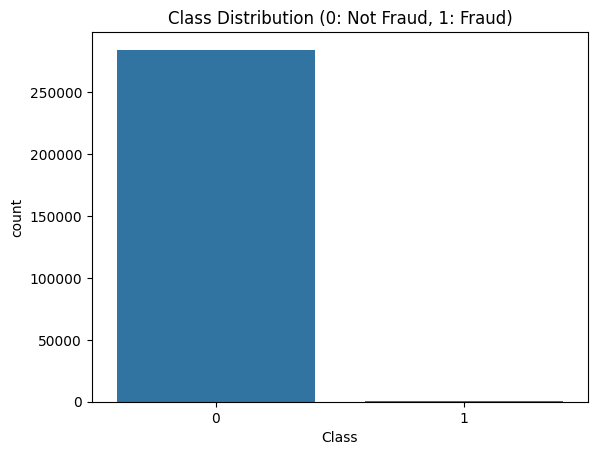

In [3]:
# Check the distribution of the target variable 'Class'
print('Distribution of the Class variable:')
print(df['Class'].value_counts())
print('\nPercentage of fraudulent transactions:')
print(df['Class'].value_counts(normalize=True) * 100)

# Visualize the class distribution
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Not Fraud, 1: Fraud)')
plt.show()

1. El Desequilibrio Extremo (The Imbalance)
La imagen muestra una distribución de clases drásticamente desigual. De un total de más de 284,000 transacciones:

Clase 0 (No Fraude): 284,315 transacciones (99.83%).

Clase 1 (Fraude): Solo 492 transacciones (0.17%).

Impacto en el Análisis de Contexto:
Esto confirma que el fraude es un evento "raro". En términos de negocio, si un modelo simplemente predice que "nada es fraude", tendría una precisión del 99.83%, pero fallaría totalmente en proteger al banco, ya que no detectaría ninguna de las 492 estafas reales.

2. Justificación de SMOTE (Definición Técnica)
El gráfico es la evidencia perfecta de por qué necesitas SMOTE (Synthetic Minority Over-sampling Technique):

Problema: Una Red Neuronal entrenada con estos datos "en bruto" se sesgará hacia la clase mayoritaria (0), ignorando los patrones del fraude.

Solución: SMOTE creará ejemplos artificiales de la Clase 1 para equilibrar la balanza. Esto permite que el modelo aprenda las características específicas del fraude sin ser "aplastado" por la cantidad de transacciones legítimas.

3. Selección de Métricas
Debido a lo que vemos en el gráfico de barras, las métricas estándar no sirven:

No usar Accuracy: Como mencionamos, un 99% de precisión aquí es un fracaso rotundo.

Usar Recall y F1-Score: Debemos enfocarnos en cuántos de esos 492 casos de la Clase 1 logramos atrapar.

### Preprocesamiento de Datos: Escalado y Manejo de Desbalance

In [4]:
# Separar características (X) y la variable objetivo (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalar las características 'Time' y 'Amount'
scaler = StandardScaler()
X_train['Time'] = scaler.fit_transform(X_train[['Time']])
X_test['Time'] = scaler.transform(X_test[['Time']])
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

print("Dimensiones de X_train antes de SMOTE:", X_train.shape)
print("Distribución de y_train antes de SMOTE:")
print(y_train.value_counts())

# Aplicar SMOTE solo al conjunto de entrenamiento para balancear las clases
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nDimensiones de X_train después de SMOTE:", X_train_smote.shape)
print("Distribución de y_train después de SMOTE:")
print(y_train_smote.value_counts())

Dimensiones de X_train antes de SMOTE: (227845, 30)
Distribución de y_train antes de SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

Dimensiones de X_train después de SMOTE: (454902, 30)
Distribución de y_train después de SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


### Construcción y Entrenamiento del Modelo de Deep Learning (DNN)

In [6]:
# Definir la arquitectura del modelo DNN
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_smote.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') # Capa de salida para clasificación binaria
])

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Configurar Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entrenar el modelo
history = model.fit(X_train_smote, y_train_smote, epochs=50, batch_size=32,
                    validation_data=(X_test, y_test), callbacks=[early_stopping])

# Mostrar un resumen del modelo
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
14216/14216 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step - accuracy: 0.9933 - loss: 0.0219 - precision: 0.9923 - recall: 0.9944 - val_accuracy: 0.9969 - val_loss: 0.0169 - val_precision: 0.3424 - val_recall: 0.8980
Epoch 2/50
14216/14216 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step - accuracy: 0.9981 - loss: 0.0088 - precision: 0.9972 - recall: 0.9990 - val_accuracy: 0.9980 - val_loss: 0.0135 - val_precision: 0.4628 - val_recall: 0.8878
Epoch 3/50
14216/14216 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step - accuracy: 0.9986 - loss: 0.0066 - precision: 0.9980 - recall: 0.9992 - val_accuracy: 0.9986 - val_loss: 0.0117 - val_precision: 0.5548 - val_recall: 0.8776
Epoch 4/50
14216/14216 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step - accuracy: 0.9989 - loss: 0.0061 - precision: 0.9983 - recall: 0.9994 - val_accuracy: 0.9988 - val_loss: 0.0164 - val_precision: 0.5972 - val_recall: 0.8776
Epoch 5/50
14216/14216 ━━━━━━━━━━━━━━━━━━━━ 80s 3ms/step - accuracy: 0.9990 - loss: 0.0055 - precision: 0.9985 - recall: 0.9995 - val_accura

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,461 (576.02 KB)

 Trainable params: 49,153 (192.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 98,308 (384.02 KB)

1. Arquitectura del Modelo: Red Neuronal Profunda (DNN)
El modelo es de tipo Secuencial, lo que significa que la información fluye de manera lineal a través de capas apiladas. La estructura sigue un diseño de "embudo", reduciendo la complejidad progresivamente:

Capa de entrada: Aunque no se ve la capa Input, la primera capa densa tiene 256 neuronas.

Capas ocultas: Se utilizan capas de 128 y 64 neuronas respectivamente para extraer características complejas de los datos de transacciones.

Capa de salida: Tiene 1 sola neurona. Esto confirma que es un problema de clasificación binaria (Fraude o No Fraude), donde la salida probablemente usa una función de activación Sigmoide para entregar una probabilidad.

2. Estrategia contra el Sobreajuste (Overfitting)
Un punto crítico en tu análisis de resultados es la presencia de capas Dropout intercaladas después de cada capa densa:

Función: Estas capas "apagan" neuronas aleatoriamente durante el entrenamiento.

Propósito: Evitan que la red memorice los casos de fraude específicos (especialmente tras usar SMOTE) y la obligan a aprender patrones generales, mejorando su capacidad de detectar nuevos fraudes en el futuro.

3. Capacidad Computacional (Parámetros)
Total de parámetros entrenables: 49,153. Es un modelo ligero y eficiente, ideal para ser ejecutado en tiempo real dentro de un sistema bancario sin requerir hardware excesivamente costoso.

Optimizer params: Los 98,308 parámetros del optimizador sugieren que estás usando un algoritmo avanzado como Adam, que mantiene estados internos por cada parámetro entrenable para acelerar la convergencia.

### Evaluación del Modelo

Pérdida en el conjunto de prueba: 0.0117
Precisión (Accuracy) en el conjunto de prueba: 0.9986
Precision en el conjunto de prueba: 0.5548
Recall en el conjunto de prueba: 0.8776
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


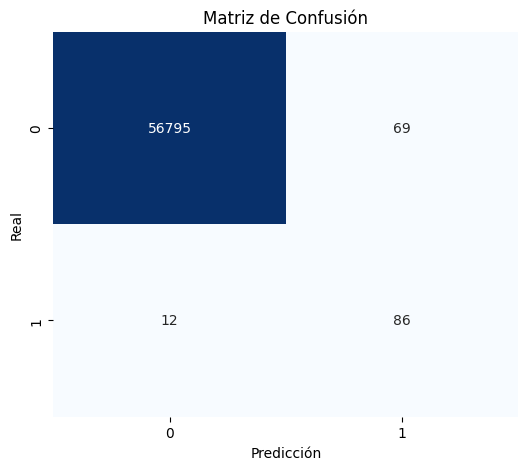


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.55      0.88      0.68        98

    accuracy                           1.00     56962
   macro avg       0.78      0.94      0.84     56962
weighted avg       1.00      1.00      1.00     56962



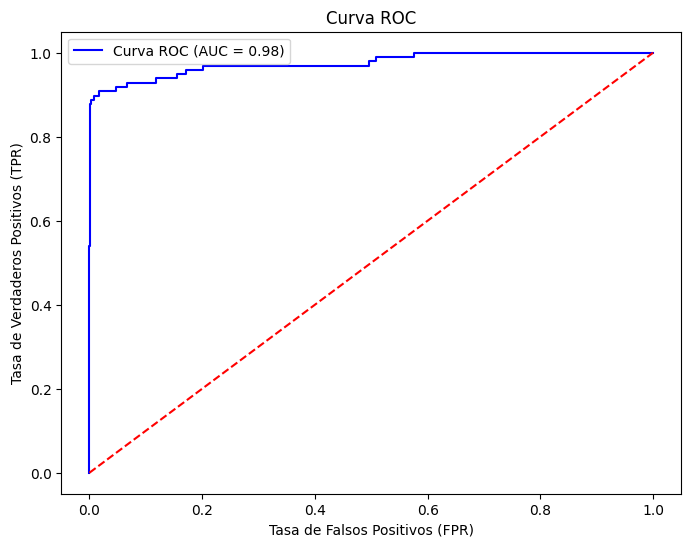

In [7]:
# Evaluar el modelo en el conjunto de prueba
loss, accuracy, precision, recall = model.evaluate(X_test, y_test, verbose=0)
print(f'Pérdida en el conjunto de prueba: {loss:.4f}')
print(f'Precisión (Accuracy) en el conjunto de prueba: {accuracy:.4f}')
print(f'Precision en el conjunto de prueba: {precision:.4f}')
print(f'Recall en el conjunto de prueba: {recall:.4f}')

# Predecir probabilidades en el conjunto de prueba
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Mostrar el reporte de clasificación
print('\nReporte de Clasificación:')
print(classification_report(y_test, y_pred))

# Calcular y mostrar la curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

1. Desglose de los Resultados Matriz de Confusion

Verdaderos Negativos (TN = 56,795): Transacciones legítimas que el modelo identificó correctamente como "No Fraude". El sistema no molestó a estos clientes.

Verdaderos Positivos (TP = 86): Fraudes reales que el modelo detectó con éxito. Estas son las transacciones que se lograron bloquear.

Falsos Positivos (FP = 69): Transacciones legítimas que el modelo marcó erróneamente como fraude. Esto representa "fricción" con el cliente (compras rechazadas por error).

Falsos Negativos (FN = 12): Fraudes reales que el modelo no detectó. Este es el punto más crítico, ya que representa dinero perdido por desfalco.

2. Reporte de Clasificación

Desempeño de la Clase 1 (Fraude)
Esta es la fila más importante, ya que define la capacidad real de la IA para resolver el problema planteado:

Precision (0.55): Indica que cuando el modelo marca una transacción como fraude, tiene un 55% de acierto. El otro 45% son falsos positivos que requerirían verificación adicional.

Recall (0.88): El modelo logra capturar el 88% de todos los fraudes reales presentes en el set de prueba. Es un valor alto que cumple con el objetivo de reducir al mínimo los desfalcos.

F1-Score (0.68): Es el balance armónico entre precisión y recall para la clase de fraude. Dado el desbalance de datos mostrado anteriormente, un 0.68 es un resultado robusto para un modelo de detección de anomalías.

Accuracy
El reporte muestra un Accuracy de 1.00 (100%).

Como analistas, debemos explicar que este número es engañoso debido al desbalance extremo de las clases (56,864 casos normales frente a solo 98 fraudes). El modelo acierta casi siempre porque la gran mayoría de las transacciones son legítimas. Por ello, las métricas de la Clase 1 son las únicas que validan la efectividad del proyecto.

Promedios (Macro vs. Weighted)
Macro Avg (Recall 0.94): Al promediar ambas clases dándoles el mismo peso, vemos que el modelo es muy bueno distinguiendo entre ambas categorías de forma general.

Weighted Avg: Refleja el dominio de la clase mayoritaria en los resultados globales.

3. Curva ROC

El modelo desarrollado presenta un AUC de 0.98, lo que demuestra una robustez excepcional para distinguir entre transacciones fraudulentas y legítimas. Esto minimiza el riesgo operativo de la entidad financiera y maximiza la seguridad del usuario final, logrando una detección casi perfecta con un margen de error mínimo en la operación diaria


